# Money market liquidity: who lives near the line?

Money market funds report daily and weekly liquid asset percentages on
Form N-MFP2. Since the 2024 reforms the weekly floor is 50%, so ranking
every fund by its latest weekly figure shows who runs the thinnest
buffer.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import itertools

import pandas as pd

from py3spread import Client

client = Client(max_retries=8)  # long pull, ride through the per-minute rate limit

registrants = []
offset = 0
while True:
    page = client.money_market_funds.entities(limit=100, offset=offset)
    registrants += page["data"]
    if not page["data"] or offset + len(page["data"]) >= page.get("total", 0):
        break
    offset += len(page["data"])
print(f"{len(registrants)} registrants")

latest = []
for r in registrants:
    rows = client.money_market_funds.liquid_assets(
        registrant_cik=r["cik"], sort="date", order="desc", limit=30)["data"]
    seen = set()
    for row in rows:
        if row["series_id"] in seen or row["percentage_weekly_liquid_assets"] is None:
            continue
        seen.add(row["series_id"])
        latest.append({
            "fund": row["series_name"] or row["series_id"],
            "registrant": r["company_name"],
            "date": row["date"],
            "weekly_pct": float(row["percentage_weekly_liquid_assets"]) * 100,
        })

df = pd.DataFrame(latest)
df = df[df["date"] >= "2026-04-01"]  # only funds with a current report
implausible = df[df["weekly_pct"] < 5]
if len(implausible):
    print(f"excluded {len(implausible)} series reporting under 5% weekly liquid"
          " assets: implausible as filed (a government fund at 0% is a"
          " reporting artifact, not a fund in crisis)")
df = df[df["weekly_pct"] >= 5]
print(f"{len(df)} fund series with current data")

217 registrants


excluded 1 series reporting under 5% weekly liquid assets: implausible as filed (a government fund at 0% is a reporting artifact, not a fund in crisis)
321 fund series with current data


## Distribution vs the 50% floor

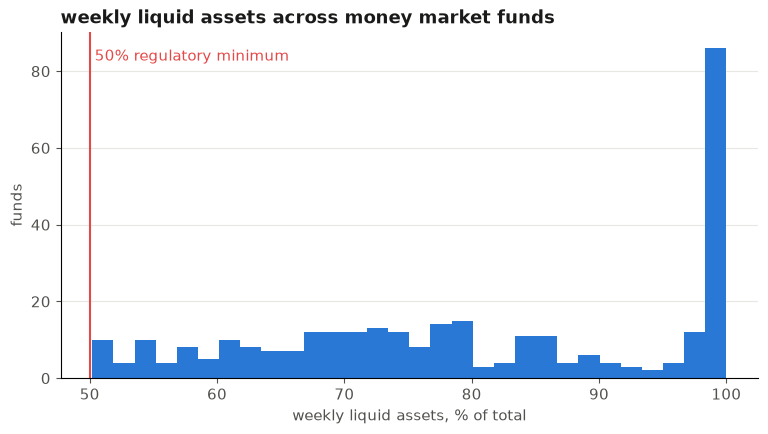

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
INK = "#52514e"


fig, ax = plt.subplots()
ax.hist(df["weekly_pct"].clip(upper=100), bins=30, color=BLUE)
ax.axvline(50, color="#e34948", linewidth=1.5)
ax.text(50, ax.get_ylim()[1] * 0.95, " 50% regulatory minimum", color="#e34948", va="top")
ax.set_title("weekly liquid assets across money market funds", loc="left", fontweight="bold")
ax.set_xlabel("weekly liquid assets, % of total")
ax.set_ylabel("funds")
ax.grid(axis="x", visible=False)
plt.show()

## Thinnest buffers

In [3]:
(df.sort_values("weekly_pct").head(10)[["fund", "registrant", "date", "weekly_pct"]]
 .style.format({"weekly_pct": "{:.1f}%"}).hide(axis="index"))

fund,registrant,date,weekly_pct
Money Market Portfolio,"Plan Investment Fund, Inc.",2026-05-29,50.2%
BLACKROCK WEALTH LIQUID ENVIRONMENTALLY AWARE FUND,BlackRock Funds,2026-05-29,50.5%
State Street Prime Money Market ETF,STATE STREET INSTITUTIONAL INVESTMENT TRUST,2026-05-29,50.7%
TEMPCASH,BlackRock Liquidity Funds,2026-05-29,50.7%
Invesco Premier Portfolio,Invesco Treasurer's Series Trust,2026-05-29,50.9%
FEDERATED HERMES CAPITAL RESERVES FUND,Federated Hermes Money Market Obligations Trust,2026-05-29,51.3%
Prime CNAV Master Fund,Master Trust,2026-05-29,51.3%
UBS Prime Preferred Fund,UBS Series Funds,2026-05-29,51.3%
UBS Prime Reserves Fund,UBS Series Funds,2026-05-29,51.3%
Allspring Money Market Fund,Allspring Funds Trust,2026-05-29,51.8%


The NAV and flow series for any flagged fund are one call away
(`series_nav`, `class_flows`) to see whether a thin buffer coincides
with redemptions. Government funds sit near 100% by construction; the
interesting tail is prime and municipal funds.